In [1]:
import numpy as np #For the array functions
import tensorflow as tf
from tensorflow import keras #we will only be using tensorflow as a backend, so we will import keras via their implementation
from tensorflow.keras import layers, models #we will use the readable keras implementation of the conv/reccurent layers

import io
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import h5py
from sklearn.model_selection import train_test_split


In [12]:
depthDF = pd.read_csv('./Subject1.txt')

poses = ["Punch_VFR","Punch_VFL","One_VFR","One_VFL","Two_VFR","Two_VFL","Three_VFR","Three_VFL","Four_VFR","Four_VFL","Five_VFR","Five_VFL","Six_VFR","Six_VFL","Seven_VFR","Seven_VFL","Eight_VFR","Eight_VFL","Nine_VFR","Nine_VFL","Span_VFR","Span_VFL","Horiz_HBL","Horiz_HFL","Horiz_HBR","Horiz_HFR","Collab","XSign","TimeOut"]

posesDF = depthDF.drop(['rgb','depth'], axis = 'columns')
posesCols = [col for col in depthDF.columns if col not in ['rgb', 'depth']]

finalColumns = ['depth', 'coordinates', 'label']

#label = [-1] * len(file)
#file['label'] = label

for index, row in depthDF.iterrows():
    filledCols = []
    #for col in posesCols:
    for col_index, col_name in enumerate(posesCols):    
        if row[col_name] != "[0 0 0 0]":
            depthDF.loc[index, 'coordinates'] = row[col_name]
            depthDF.loc[index, 'label'] = col_index
            filledCols.append(row[col_name])

    if len(filledCols) != 1:
        depthDF = depthDF.drop(index, axis='rows')

for col_name in depthDF.columns:
    if(col_name not in finalColumns):
        depthDF = depthDF.drop(col_name, axis='columns')

print(depthDF)

                                 depth        coordinates  label
5     ..\Subject2\Depth\3791_depth.png  [412 283 103 109]   27.0
7     ..\Subject2\Depth\3789_depth.png  [410 281 105 111]   27.0
8     ..\Subject2\Depth\3737_depth.png   [416 284 97 109]   27.0
10    ..\Subject2\Depth\5145_depth.png  [413 284 103 109]   27.0
13    ..\Subject2\Depth\3813_depth.png  [415 288 101 111]   27.0
...                                ...                ...    ...
2354  ..\Subject2\Depth\3451_depth.png    [408 358 96 59]   26.0
2364  ..\Subject2\Depth\3429_depth.png   [394 349 100 67]   26.0
2367  ..\Subject2\Depth\3741_depth.png   [416 282 97 111]   27.0
2370  ..\Subject2\Depth\3485_depth.png    [415 357 89 53]   26.0
2393  ..\Subject2\Depth\3584_depth.png   [411 277 95 104]   28.0

[450 rows x 3 columns]


802.0


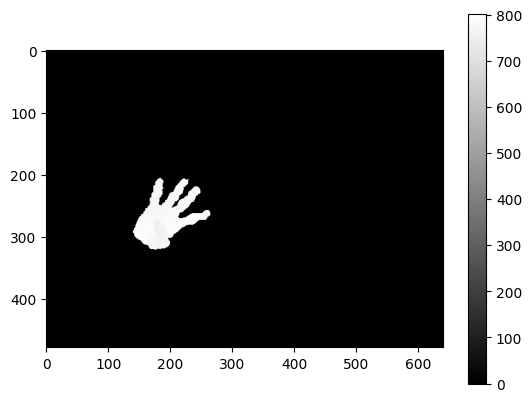

186 341 120 284
801.84485


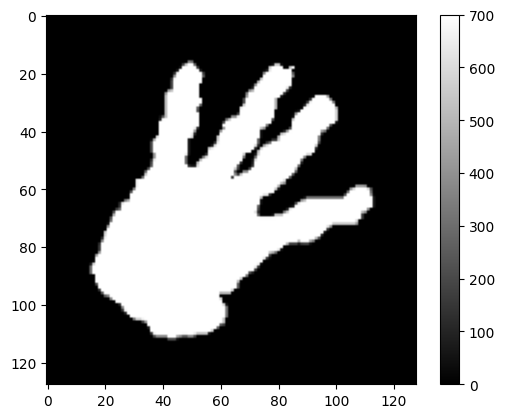

In [4]:
depthMap = pd.read_csv('Depth Images/P2/G5/1.txt')
#depthArray = depthArray.reshape((480, 640))

k = 0
threshold = (np.min(depthMap[depthMap>k])) + 50
print(threshold)

depth = np.array(depthMap, dtype=np.float32)
#depth[depth == 0] = np.nan
depth[depth > threshold] = 0


plt.imshow(depth, cmap='gray')
plt.colorbar()
plt.show()

mask = depth > 0
mask = mask.astype(np.uint8)


num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

clean_mask = (labels == largest_label).astype(np.uint8)

depth = depth * clean_mask
ys, xs = np.where(depth>0)


padding = 20

ymin, ymax = max(0, ys.min() - padding), max(0, ys.max() + padding)
xmin, xmax = max(0, xs.min() - padding), max(0, xs.max() + padding)

print(ymin, ymax, xmin, xmax)
hand_crop = depth[ymin:ymax, xmin:xmax]
hand_crop = cv2.resize(hand_crop, (128, 128))

print(hand_crop.max())
plt.imshow(hand_crop, cmap='gray')
plt.clim(0, 700)
plt.colorbar()
plt.show()


In [5]:


def imagePreProcess(depthMap, label):
    depth = np.array(depthMap, dtype=np.float32)
    k = 0
    threshold = (np.min(depthMap[depthMap>k])) + 75

    depth = np.array(depthMap, dtype=np.float32)
    depth[depth > threshold] = 0

    mask = depth > 0
    mask = mask.astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    clean_mask = (labels == largest_label).astype(np.uint8)

    depth = depth * clean_mask

    ys, xs = np.where(depth>0)

    padding = 20

    ymin, ymax = max(0, ys.min() - padding), max(0, ys.max() + padding)
    xmin, xmax = max(0, xs.min() - padding), max(0, xs.max() + padding)


    hand_crop = depth[ymin:ymax, xmin:xmax]
    hand_crop = cv2.resize(hand_crop, (128, 128))

    allImages.append(hand_crop)
    allLabels.append(label)

    #print(hand_crop.max())
    #plt.imshow(hand_crop, cmap='gray')
    #plt.clim(0, 800)
    #plt.colorbar()
    #plt.show()

def createFile():
    with h5py.File("gesture_dataset.h5", "w") as f:
        f.create_dataset("images", data=allImages, compression="gzip")
        f.create_dataset("labels", data=allLabels)

def main():

    # List of directories
    for root, dirs, files in os.walk("Depth Images"):
        path = root.split(os.sep)
        fileNames = []

        allImages = []
        allLabels = []
        print(path)
        for file in files:
            fileNames.append(file)
        
        if (len(fileNames) > 0):
            for index, file in enumerate(files):
                curFile = fileNames[index]
                filePath = (os.path.join(root, curFile))
                
                depthMap = pd.read_csv(filePath)
                #label = curFile.split('.')[0]
                label = int(path[len(path)-1].split('G')[1]) - 1
                print(label)
                imagePreProcess(depthMap, label)
    createFile()

allImages = []
allLabels = []
main()
        


['Depth Images']
['Depth Images', 'P1']
['Depth Images', 'P1', 'G1']
0
0
0
0
0
0
0
0
0
0
['Depth Images', 'P1', 'G10']
9
9
9
9
9
9
9
9
9
9
['Depth Images', 'P1', 'G2']
1
1
1
1
1
1
1
1
1
1
['Depth Images', 'P1', 'G3']
2
2
2
2
2
2
2
2
2
2
['Depth Images', 'P1', 'G4']
3
3
3
3
3
3
3
3
3
3
['Depth Images', 'P1', 'G5']
4
4
4
4
4
4
4
4
4
4
['Depth Images', 'P1', 'G6']
5
5
5
5
5
5
5
5
5
5
['Depth Images', 'P1', 'G7']
6
6
6
6
6
6
6
6
6
6
['Depth Images', 'P1', 'G8']
7
7
7
7
7
7
7
7
7
7
['Depth Images', 'P1', 'G9']
8
8
8
8
8
8
8
8
8
8
['Depth Images', 'P10']
['Depth Images', 'P10', 'G1']
0
0
0
0
0
0
0
0
0
0
['Depth Images', 'P10', 'G10']
9
9
9
9
9
9
9
9
9
9
['Depth Images', 'P10', 'G2']
1
1
1
1
1
1
1
1
1
1
['Depth Images', 'P10', 'G3']
2
2
2
2
2
2
2
2
2
2
['Depth Images', 'P10', 'G4']
3
3
3
3
3
3
3
3
3
3
['Depth Images', 'P10', 'G5']
4
4
4
4
4
4
4
4
4
4
['Depth Images', 'P10', 'G6']
5
5
5
5
5
5
5
5
5
5
['Depth Images', 'P10', 'G7']
6
6
6
6
6
6
6
6
6
6
['Depth Images', 'P10', 'G8']
7
7
7
7
7
7
7


In [22]:
with h5py.File('gesture_dataset.h5', 'r') as file:
    print(file)
    a_group_key = list(file.keys())[1]
    data = list(file[a_group_key])

    X = file['images'][:]
    y = file['labels'][:]    
    # Getting the data

X = np.array([depthImage / X.max() for depthImage in X])
y = np.array([label for label in y])

X = np.expand_dims(X, axis=-1)

#X = X.reshape(None, 1000, 128, 128)
#X = np.expand_dims(X, axis=-1)

train_images, test_images, train_labels, test_labels = train_test_split(
    X, y, test_size=0.25, random_state=42)

print(train_images.shape)
print(train_images.dtype)
print(train_images.min(), train_images.max())

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.05)
])

model = models.Sequential()
model.add(data_augmentation)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.summary()

model.add(layers.Flatten()) 
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
#model.add(layers.Dense(10))
#model.add(layers.Dense(128, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
#                    bias_regularizer=regularizers.l1(0.006) ,activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )



history = model.fit(train_images, train_labels, epochs=60, batch_size = 16,
                    validation_data=(test_images, test_labels))

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)



<HDF5 file "gesture_dataset.h5" (mode r)>
(750, 128, 128, 1)
float32
0.0 1.0


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_38 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.2573 - loss: 2.0911 - val_accuracy: 0.6280 - val_loss: 1.2706
Epoch 2/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.5560 - loss: 1.3353 - val_accuracy: 0.7280 - val_loss: 0.8267
Epoch 3/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7080 - loss: 0.8843 - val_accuracy: 0.8120 - val_loss: 0.5789
Epoch 4/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7693 - loss: 0.6718 - val_accuracy: 0.8640 - val_loss: 0.4757
Epoch 5/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8280 - loss: 0.5668 - val_accuracy: 0.8680 - val_loss: 0.4297
Epoch 6/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8440 - loss: 0.4555 - val_accuracy: 0.8600 - val_loss: 0.3929
Epoch 7/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8627 - loss: 0.3807 - val_accuracy: 0.8840 - val_loss: 0.3677
Epoch 8/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.8773 - loss: 0.3656 - val_accuracy: 0.9040 -

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


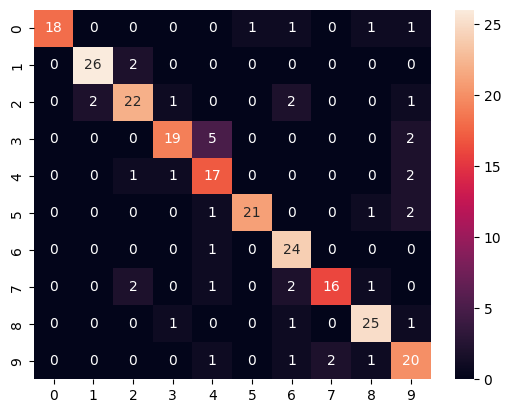

In [14]:
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(test_labels, predicted_classes)
sns.heatmap(cm, annot=True)
plt.show()